# Importing Packages


*Explain the project here*

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
import numpy as np
import tensorflow.keras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization, Dropout
# from sklearn.metrics import confusion_matrix
from mlxtend.evaluate import confusion_matrix
import itertools
import matplotlib.pyplot as plt
%matplotlib inline
print("Import Success!")

Import Success!


# Downloading the data:

In [ ]:
!pip install gdown --quiet
import gdown

# Using a direct download link instead of a view link
url = 'https://drive.google.com/uc?id=1Q68b84U1RhiHfGEi3jD6sdCElM5R2DBw'
output = 'bccd2.zip'
gdown.download(url, output, quiet=True)

import os
print(os.path.getsize('bccd2.zip'))

6149643


In [ ]:
!unzip bccd2.zip
print("Done.")

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/bccd2/Test/Neutrophil/._3070.jpg  
  inflating: bccd2/Test/Neutrophil/3064.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._3064.jpg  
  inflating: bccd2/Test/Neutrophil/3058.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._3058.jpg  
  inflating: bccd2/Test/Neutrophil/2965.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2965.jpg  
  inflating: bccd2/Test/Neutrophil/2971.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2971.jpg  
  inflating: bccd2/Test/Neutrophil/2959.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2959.jpg  
  inflating: bccd2/Test/Neutrophil/2958.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2958.jpg  
  inflating: bccd2/Test/Neutrophil/2970.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2970.jpg  
  inflating: bccd2/Test/Neutrophil/2964.jpg  
  inflating: __MACOSX/bccd2/Test/Neutrophil/._2964.jpg  
  inflating: bccd2/Test/Neutrophil/3059.jpg  
  inflating: __MACOSX/

In [ ]:
!find . -name '.DS_Store' -type f -delete

train_path = 'bccd2/Train/'
test_path = 'bccd2/Test/'

print("Paths Loaded.")

Paths Loaded.


DATA AUGMENTATION

In [ ]:
image_size = (240, 240)
classes = ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

train_datagen = ImageDataGenerator(validation_split=0.25) # set validation split

train_batches = train_datagen.flow_from_directory(train_path, image_size, classes=classes, batch_size=15, subset='training')
valid_batches = train_datagen.flow_from_directory(train_path, image_size, classes=classes, batch_size=8, subset='validation')
test_batches = ImageDataGenerator().flow_from_directory(test_path, image_size, classes=classes, batch_size=133)

Found 1125 images belonging to 5 classes.
Found 375 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.


DATA PREPROCESSING

In [ ]:
# Get class indices from the train_batches generator
class_indices = train_batches.class_indices

# Initialize a dictionary to store class counts
class_counts = {class_name: 0 for class_name in class_indices}

# Count instances in the training set
for _ in range(train_batches.samples // train_batches.batch_size + 1):
    _, labels = next(train_batches)
    for label in labels:
        class_name = classes[np.argmax(label)]
        class_counts[class_name] += 1

# Count instances in the test set
for _ in range(test_batches.samples // test_batches.batch_size + 1):
    _, labels = next(test_batches)
    for label in labels:
        class_name = classes[np.argmax(label)]
        class_counts[class_name] += 1

# Print the class counts
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Basophil: 529
Eosinophil: 528
Lymphocyte: 530
Monocyte: 525
Neutrophil: 528


DATA VISUALIZATION

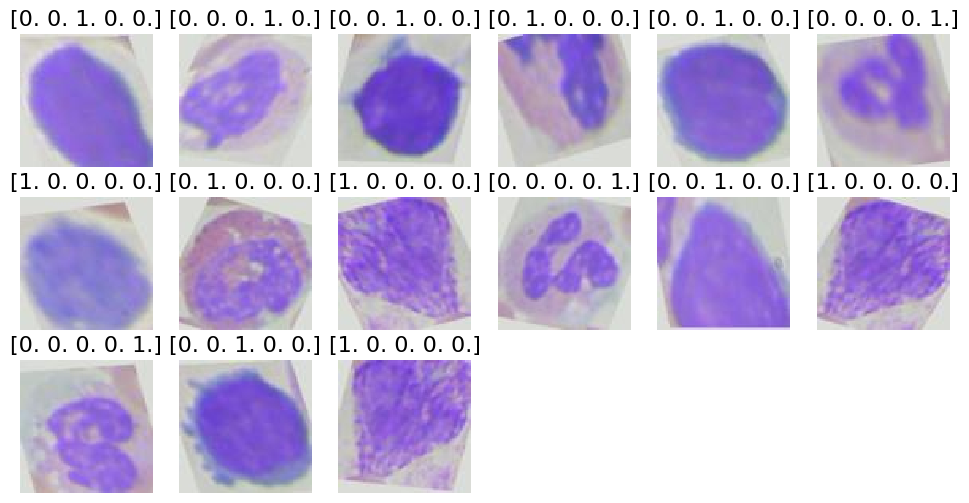

In [ ]:
# plot function, used to plot images with labels
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims= np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

imgs, labels = next(train_batches)

# we plot these samples of images and their labels 1 batch at a time.
plots(imgs, titles=labels, rows=3)

In [ ]:
imgs, labels = next(train_batches)
print("Image shape:", imgs.shape)
print("Image data type:", imgs.dtype)
print("Image min/max:", imgs.min(), imgs.max())

Image shape: (15, 240, 240, 3)
Image data type: float32
Image min/max: 55.0 255.0


LOADING MODEL

In [ ]:
from keras.applications.resnet import ResNet50
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load the ResNet50 model with the correct input shape and without the top classification layers
ResNet50_model = ResNet50(weights='imagenet', include_top=False, input_shape=(240, 240, 3))

# Create a new model
model = Sequential()

# Add the ResNet50 base model
model.add(ResNet50_model)

# Add a GlobalAveragePooling2D layer to reduce the spatial dimensions
model.add(GlobalAveragePooling2D())

# Add a Dense layer for classification with the desired number of classes
model.add(Dense(len(classes), activation='softmax'))

# Add dropout after a Dense layer
model.add(Dropout(0.1))

# Freeze the layers of the ResNet50 base model
for layer in ResNet50_model.layers:
    layer.trainable = False

for layer in ResNet50_model.layers[-5:]:  # Unfreeze the last layers (adjust as needed)
    layer.trainable = True

# Print the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 8, 8, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │          10,245 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 1,064,965 (4.06 MB)

 Non-trainable params: 22,532,992 (85.96 MB)

In [ ]:
# Compiling the model with an inital leaning rate of 0.001
# Switching learning rate from 0.001 to 0.0001. Checking to see if it will fix the training loss and accuracy issues.
optimizer = Adam(learning_rate=0.0001, clipvalue=10.0)

model.compile(optimizer,
               loss='categorical_crossentropy',
               metrics=['accuracy'])
print("Done")

Done


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_batches.classes), y=train_batches.classes)

# Convert class weights to a dictionary
class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)
print("Done")

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}
Done


In [ ]:
history = model.fit(
    train_batches,
    steps_per_epoch=train_batches.samples // 14,
    validation_data=valid_batches,
    validation_steps=valid_batches.samples // 8,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict  # Add class weights here
)

print("Training Complete!")

Epoch 1/10
75/80 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9102 - loss: 1.4265

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.9097 - loss: 1.4362 - val_accuracy: 0.9402 - val_loss: 0.1642
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8826 - loss: 1.8982 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.8809 - loss: 1.9230 - val_accuracy: 0.9457 - val_loss: 0.1620
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.8845 - loss: 1.8648 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8982 - loss: 1.6440 - val_accuracy: 0.9429 - val_loss: 0.1611
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.9135 - loss: 1.3957 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9057 - loss: 1.5228 - val_accuracy: 0.9457 - val_loss: 0.1671
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8836 - loss: 1.8783 - val_accuracy: 1.0000 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_batches,
                                     steps=1,
                                     verbose=0)
print(test_loss)
print(test_acc)

0.09999744594097137
0.969924807548523


In [ ]:
test_imgs, test_labels = next(test_batches)
predictions = model.predict(test_batches, steps=1, verbose=0)

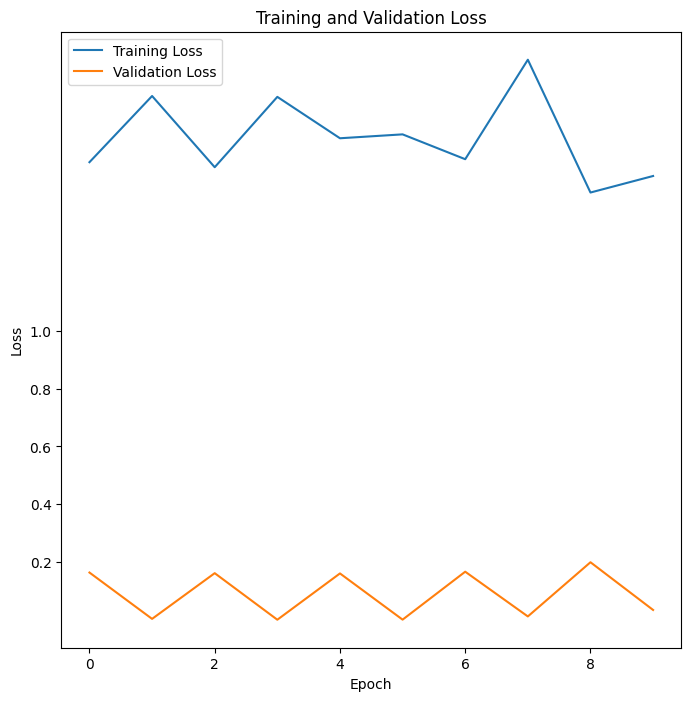

In [ ]:
# Plot Training and Validation Metrics, and Confusion Matrix
plt.figure(figsize=(8, 8)) #default was 18,

# Plot Training and Validation Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0]) # added this
plt.legend()

Confusion matrix, without normalization
[[1 4 5 5 4]
 [5 7 6 7 6]
 [9 3 5 5 5]
 [8 5 3 9 4]
 [3 7 4 8 5]]


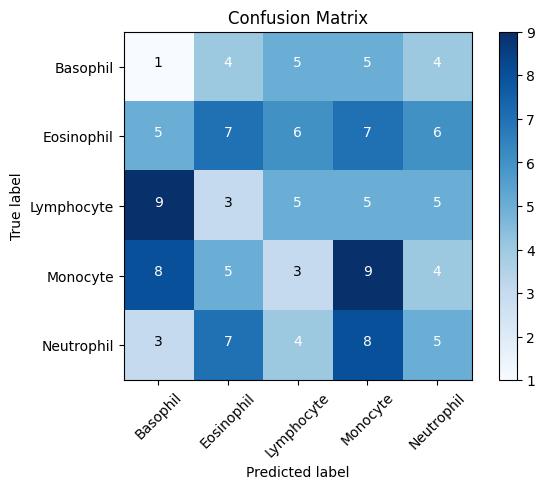

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    # thresh = cm.max() / 2.
    # for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    #     plt.text(j, i, cm[i, j],
    #              horizontalalignment="center",
    #              color="white" if cm[i, j] > thresh else "black")

    thresh = cm.max() / 3.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot Confusion Matrix
cm = confusion_matrix(test_labels.argmax(axis=1), predictions.argmax(axis=1))
plot_confusion_matrix(cm, classes, title='Confusion Matrix')

plt.show()